# NYC Climate Budgeting Report — Exploration

Climate Alignment Assessment & Capital Climate Investments (published 2026-06-24).

Each row is a **(project, financial plan, fiscal year)** funding line, so a single project appears many times. Keep that in mind when aggregating — drop duplicates or group before you sum dollars.

In [ ]:
import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Raw CSVs live in the repo's data/ folder (gitignored). Resolve whether the
# notebook kernel runs from the repo root or from notebooks/.
DATA = "data" if os.path.isdir("data") else "../data"
CSV = f"{DATA}/NYC_Climate_Budgeting_Report__Climate_Alignment_Assessment_and_Capital_Climate_Investments_20260624.csv"

In [2]:
# Load. The file is ~67 MB / ~260k rows, so this takes a few seconds.
# 'Fiscal Year Amount' and 'Fiscal Year' have thousands separators -> read as str, clean below.
df = pd.read_csv(CSV, dtype=str, keep_default_na=True, na_values=[""])
print(df.shape)
df.head()

(259491, 19)


,Published Date,Project Id,Project Description,Budget Line,Budget Line Title,Asset Category,Greenhouse Gas (GHG) Mitigation Tracking Category,Flood Resiliency Tracking Category,Heat Resiliency Tracking Category,Heat Vulnerability Index,Flood Vulnerability Index,Greenhouse Gas (GHG) Mitigation,Flood Resiliency,Heat Resiliency,Environmental and Social Benefits,Financial Plan,Fiscal Year,Fiscal Year Amount,Remarks
0,04/24/2024,035 L21FREEZE,NYPL Research Libraries - Blast Freezer,L 0101,NaN,Equipment,NaN,NaN,NaN,NaN,NaN,Pending Rating,No Impact,No Impact,NaN,Fiscal Year 2025 Executive Budget,"2,025",0,NaN
1,04/24/2024,035 L21FREEZE,NYPL Research Libraries - Blast Freezer,L 0101,NaN,Equipment,NaN,NaN,NaN,NaN,NaN,Pending Rating,No Impact,No Impact,NaN,Fiscal Year 2025 Executive Budget,"2,026",393,NaN
2,04/24/2024,035 L21FREEZE,NYPL Research Libraries - Blast Freezer,L 0101,NaN,Equipment,NaN,NaN,NaN,NaN,NaN,Pending Rating,No Impact,No Impact,NaN,Fiscal Year 2025 Executive Budget,"2,027",0,NaN
3,04/24/2024,035 L21FREEZE,NYPL Research Libraries - Blast Freezer,L 0101,NaN,Equipment,NaN,NaN,NaN,NaN,NaN,Pending Rating,No Impact,No Impact,NaN,Fiscal Year 2025 Executive Budget,"2,028",0,NaN
4,04/24/2024,035 L21FREEZE,NYPL Research Libraries - Blast Freezer,L 0101,NaN,Equipment,NaN,NaN,NaN,NaN,NaN,Pending Rating,No Impact,No Impact,NaN,Fiscal Year 2025 Executive Budget,"2,029",0,NaN


In [3]:
# Clean numeric columns (strip commas)
df["Fiscal Year Amount"] = (
    df["Fiscal Year Amount"].str.replace(",", "", regex=False).astype(float)
)
df["Fiscal Year"] = (
    df["Fiscal Year"].str.replace(",", "", regex=False).astype("Int64")
)
df["Published Date"] = pd.to_datetime(df["Published Date"], errors="coerce")
df.dtypes

Published Date                                       datetime64[us]
Project Id                                                      str
Project Description                                             str
Budget Line                                                     str
Budget Line Title                                               str
Asset Category                                                  str
Greenhouse Gas (GHG) Mitigation Tracking Category               str
Flood Resiliency Tracking Category                              str
Heat Resiliency Tracking Category                               str
Heat Vulnerability Index                                        str
Flood Vulnerability Index                                       str
Greenhouse Gas (GHG) Mitigation                                 str
Flood Resiliency                                                str
Heat Resiliency                                                 str
Environmental and Social Benefits               

In [4]:
# Column overview: dtype, non-null count, and # unique values
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "nunique": df.nunique(dropna=True),
})
overview

,dtype,non_null,nunique
Published Date,datetime64[us],259491,3
Project Id,str,259491,12126
Project Description,str,259331,11834
Budget Line,str,259326,1795
Budget Line Title,str,258957,1312
Asset Category,str,251591,17
Greenhouse Gas (GHG) Mitigation Tracking Category,str,20919,31
Flood Resiliency Tracking Category,str,8665,23
Heat Resiliency Tracking Category,str,15397,10
Heat Vulnerability Index,str,96908,2


In [5]:
# Value counts for the categorical climate-tracking columns
cat_cols = [
    "Asset Category",
    "Greenhouse Gas (GHG) Mitigation Tracking Category",
    "Flood Resiliency Tracking Category",
    "Heat Resiliency Tracking Category",
    "Greenhouse Gas (GHG) Mitigation",
    "Flood Resiliency",
    "Heat Resiliency",
    "Financial Plan",
]
for c in cat_cols:
    print(f"=== {c} ===")
    print(df[c].value_counts(dropna=False).head(15))
    print()

=== Asset Category ===
Asset Category
Buildings & Facilities          97701
Street & Road Projects          26525
Equipment                       25883
Public Space & Recreation       18822
Green & Natural Space           14027
Sewers & Grey Infrastructure    13455
IT & Technology                 12258
Vehicles                         8211
Waterfront Assets                7995
Water Supply Infrastructure      7907
NaN                              7900
Special Projects                 4666
Energy & Utilities               4277
It & Technology                  3630
Other                            2180
Name: count, dtype: int64

=== Greenhouse Gas (GHG) Mitigation Tracking Category ===
Greenhouse Gas (GHG) Mitigation Tracking Category
NaN                                                           238572
Net-Zero Compatible (non-ACE)                                   5560
Buildings & Facilities - other than ACE Projects                4818
Buildings & Facilities - ACE Projects             

In [6]:
# Spending by fiscal year (raw sum across all financial plans).
# NOTE: multiple financial plans (e.g. successive budget updates) overlap,
# so this double-counts unless you pick one plan. See next cell.
df.groupby("Fiscal Year")["Fiscal Year Amount"].sum()

Fiscal Year
2025    43807370.0
2026    77305633.0
2027    68116340.0
2028    61400873.0
2029    58300414.0
2030    34880647.0
2031    13963803.0
2032    12636763.0
2033    14567003.0
2034    13017088.0
2035    13479958.0
Name: Fiscal Year Amount, dtype: float64

In [7]:
# Pick the most recent financial plan to avoid double-counting across budget revisions
plans = df["Financial Plan"].unique()
print("Financial plans available:")
for p in plans:
    print("  ", p)

latest_plan = df.sort_values("Published Date")["Financial Plan"].dropna().iloc[-1]
print("\nUsing:", latest_plan)
latest = df[df["Financial Plan"] == latest_plan]

Financial plans available:
   Fiscal Year 2025 Executive Budget
   Fiscal Year 2026 Executive Budget

Using: Fiscal Year 2026 Executive Budget


In [8]:
# Spend by GHG mitigation rating within the latest plan
(latest.groupby("Greenhouse Gas (GHG) Mitigation")["Fiscal Year Amount"]
        .sum()
        .sort_values(ascending=False))

Greenhouse Gas (GHG) Mitigation
No Impact                           124167357.0
Special Projects                     66987396.0
Pending Rating                       58805291.0
Aligned Component                    39178904.0
Aligned                              13125475.0
Not Aligned                           6425335.0
Not Aligned (Short-Term Benefit)      5125550.0
Name: Fiscal Year Amount, dtype: float64

In [9]:
# Top projects by total funding in the latest plan
(latest.groupby(["Project Id", "Project Description"])["Fiscal Year Amount"]
        .sum()
        .sort_values(ascending=False)
        .head(20))

Project Id                  Project Description                                         
040 SCA26                   SCA26                                                           8576662.0
040 SCA27                   SCA27                                                           7981309.0
850 BBJ-M                   Boro Based Jail New Manhattan Detention Facility DesignBuild    7917734.0
040 SCA28                   SCA28                                                           7637540.0
850 BBJ-Q                   Boro Based Jails New Queens Detention Facility DesignBuild      7301720.0
040 SCA29                   SCA29                                                           7253510.0
850 BBJ-X                   Boro Based Jails New Bronx Detention Facility DesignBuild       5672702.0
826 CS-NC-CST               NEWTOWN CREEK CSO STORAGE TUNNEL                                4949863.0
040 SCA25                   SCA25                                                           413

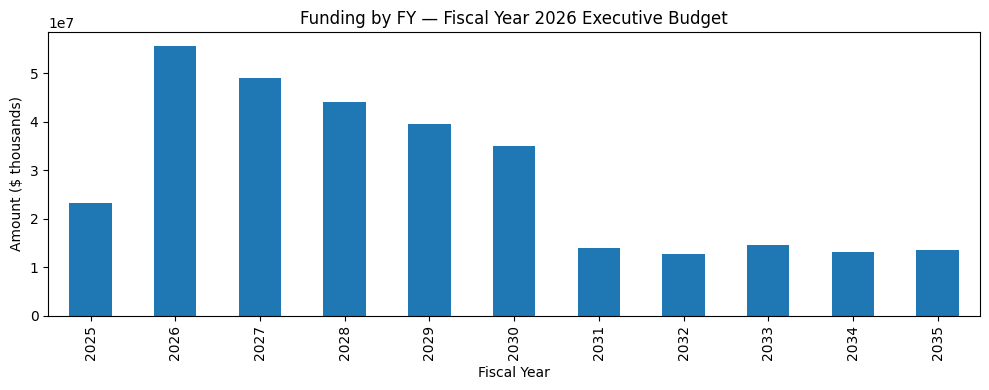

In [10]:
# Quick chart: total funding by fiscal year for the latest plan
import matplotlib.pyplot as plt

by_year = latest.groupby("Fiscal Year")["Fiscal Year Amount"].sum()
ax = by_year.plot(kind="bar", figsize=(10, 4), title=f"Funding by FY — {latest_plan}")
ax.set_ylabel("Amount ($ thousands)")
plt.tight_layout()
plt.show()

## Scratch
Free space below for your own slicing.

Handy column reference: `Heat Vulnerability Index`, `Flood Vulnerability Index`, `Asset Category`, `Budget Line Title`, `Environmental and Social Benefits`, `Remarks`.

## Map: geolocated climate capital investments

Uses `climate_budget_geolocated.csv`, which joins each climate-budget funding line to its
project location from the Capital Projects Database (CPDB). Join key: CPDB `maprojid` ↔
climate `Project Id` (whitespace-normalized). See `build_climate_budget_geolocated.py`.

The file keeps every publication snapshot (`published_date` × `financial_plan`), so we filter
to the **latest snapshot** before summing dollars — otherwise successive budget revisions
double-count. Each point is one project; size/color = total $ allocated across its fiscal years.

In [ ]:
# Load the geolocated climate-budget CSV and aggregate to one row per project.
# (Generate it first with: python scripts/build_climate_budget_geolocated.py)
import plotly.express as px

geo = pd.read_csv(f"{DATA}/climate_budget_geolocated.csv", low_memory=False)

# Filter to the most recent publication snapshot (one financial plan -> no double-counting)
latest_snapshot = geo["published_date"].max()
snap = geo[geo["published_date"] == latest_snapshot].copy()
print("Snapshot:", latest_snapshot, "|", snap["financial_plan"].iloc[0])

# Total $ allocated per project across all its fiscal years (amounts are $ thousands)
proj = (
    snap.groupby(
        ["join_id", "maprojid", "agency_name", "project_description",
         "asset_category", "longitude", "latitude"],
        dropna=False,
    )["fiscal_year_amount"]
    .sum()
    .reset_index()
    .rename(columns={"fiscal_year_amount": "total_allocation_k"})
)
proj = proj[proj["total_allocation_k"] > 0]  # drop $0 placeholder projects
proj["total_allocation_m"] = proj["total_allocation_k"] / 1_000  # $ millions

print(f"{len(proj):,} geolocated projects | "
      f"${proj['total_allocation_k'].sum()/1e6:,.1f}B total allocated")
proj.sort_values("total_allocation_k", ascending=False).head()

In [ ]:
# Interactive map: one dot per project, size & color = total $ allocated.
fig = px.scatter_mapbox(
    proj,
    lat="latitude",
    lon="longitude",
    size="total_allocation_m",
    color="total_allocation_m",
    color_continuous_scale="Viridis",
    size_max=28,
    zoom=9.3,
    center={"lat": 40.71, "lon": -73.95},
    hover_name="project_description",
    hover_data={
        "agency_name": True,
        "asset_category": True,
        "total_allocation_m": ":.1f",
        "maprojid": True,
        "latitude": False,
        "longitude": False,
    },
    labels={"total_allocation_m": "Allocation ($M)"},
    mapbox_style="open-street-map",
    title=f"NYC climate capital investments by location — {snap['financial_plan'].iloc[0]}",
    height=720,
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()